### Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Read the csv file

In [2]:
ecommerce=pd.read_csv("ecommerceDataset.csv")

### Assign column names

In [3]:
cols=["target","text"]
ecommerce.columns=cols

In [4]:
ecommerce.head()

,target,text
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...


### check the shape of the data
- 50424 rows and 2 columns present in the dataset

In [5]:
ecommerce.shape

(50424, 2)

### Check duplicates
- Duplicate values present in the large amount in this data that is 22622

In [6]:
ecommerce.duplicated().sum()

22622

### Droping duplicates

In [7]:
ecommerce.drop_duplicates(inplace=True)

### checking duplicates after dropping it

In [8]:
ecommerce.duplicated().sum()

0

### Information about the data
- 27802 entries in the data
- two categorical features present

In [9]:
ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27802 entries, 0 to 50409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  27802 non-null  object
 1   text    27801 non-null  object
dtypes: object(2)
memory usage: 651.6+ KB


### Check null values
- single null value present in the text column

In [10]:
ecommerce.isna().sum()

target    0
text      1
dtype: int64

### Drop null values

In [11]:
ecommerce.dropna(inplace=True)

### unique values 
- target feature consisting four unique values (Household 10563, Books 6256, Clothing & Accessories 5675, Electronics 5308) 

In [12]:
ecommerce.target.value_counts()

target
Household                 10563
Books                      6256
Clothing & Accessories     5674
Electronics                5308
Name: count, dtype: int64

### Pie chart
- Pie chart to show the distribution of each category in percentage
- Household consists 38% of values which is the most among present categories
- Rest consisting close to 20 % each

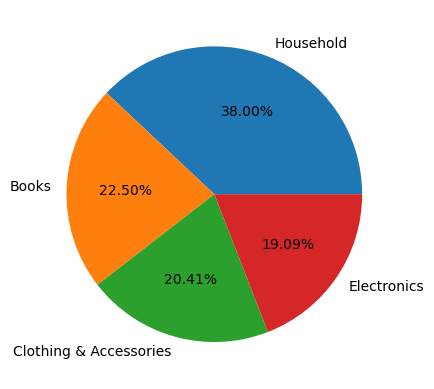

In [13]:
plt.pie(ecommerce["target"].value_counts().values, labels=ecommerce["target"].value_counts().index, autopct="%0.2f%%")
plt.show()

### Convert categorical to numerical
- convert categories in target column to numerical to proceed for further model building

In [14]:
ecommerce["target"]=ecommerce["target"].replace({"Household":0,"Electronics":1,"Clothing & Accessories":2,"Books":3}, regex=True)

C:\Users\Manisha\AppData\Local\Temp\ipykernel_14796\2443193451.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ecommerce["target"]=ecommerce["target"].replace({"Household":0,"Electronics":1,"Clothing & Accessories":2,"Books":3}, regex=True)


### Cleaning text
- create a function to clean text removing digits using regex
- tokenizing text using word tokenize to split text into words
- use stopwords to keep english language words
- lemmatize the words using wordnetlemmatizer

In [18]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\d+','', text)
    text=re.sub(r'[^\w\s]','', text)
    words=word_tokenize(text)
    words=[word for word in words if word not in stopwords.words("english")]
    lemmatizer=WordNetLemmatizer()
    words=[lemmatizer.lemmatize(word) for word in words]
    text=" ".join(words)
    return text

### apply function on dataframe
- clean text fuction used on text data 

In [34]:
ecommerce=ecommerce.sample(4000)

In [19]:
ecommerce["cleaned_text"]=ecommerce["text"].apply(clean_text)

In [20]:
ecommerce.head()

,target,text,cleaned_text
0,0,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",saf floral framed painting wood inch x inch sp...
1,0,SAF 'UV Textured Modern Art Print Framed' Pain...,saf uv textured modern art print framed painti...
2,0,"SAF Flower Print Framed Painting (Synthetic, 1...",saf flower print framed painting synthetic inc...
3,0,Incredible Gifts India Wooden Happy Birthday U...,incredible gift india wooden happy birthday un...
4,0,Pitaara Box Romantic Venice Canvas Painting 6m...,pitaara box romantic venice canvas painting mm...


### word cloud 

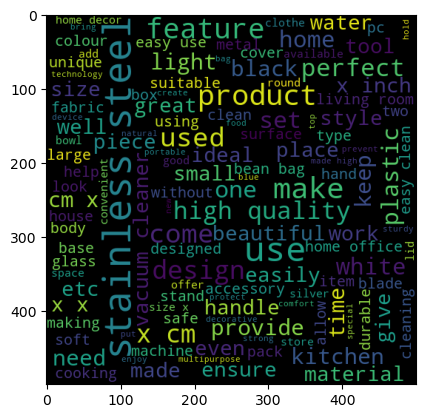

In [23]:
wc=WordCloud(width=500, height=500, min_font_size=10)
ecommerce_wc=wc.generate(ecommerce[ecommerce["target"]==0]["cleaned_text"].str.cat(sep=" "))
plt.imshow(ecommerce_wc)

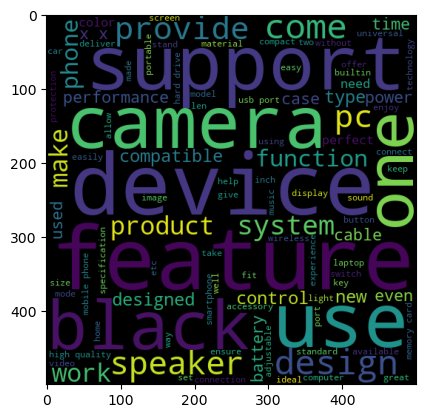

In [24]:
wc=WordCloud(width=500, height=500, min_font_size=10)
ecommerce_wc=wc.generate(ecommerce[ecommerce["target"]==1]["cleaned_text"].str.cat(sep=" "))
plt.imshow(ecommerce_wc)

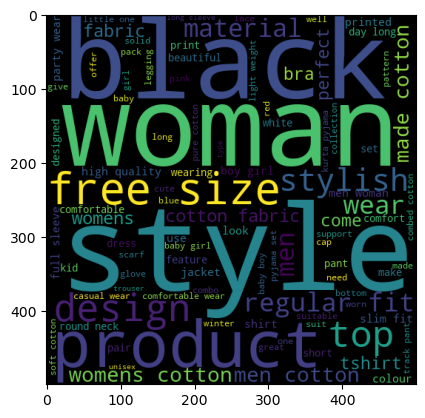

In [25]:
wc=WordCloud(width=500, height=500, min_font_size=10)
ecommerce_wc=wc.generate(ecommerce[ecommerce["target"]==2]["cleaned_text"].str.cat(sep=" "))
plt.imshow(ecommerce_wc)

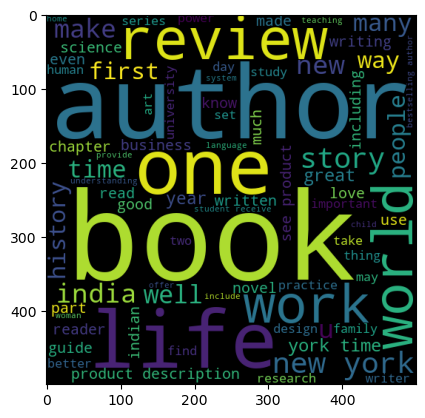

In [26]:
wc=WordCloud(width=500, height=500, min_font_size=10)
ecommerce_wc=wc.generate(ecommerce[ecommerce["target"]==3]["cleaned_text"].str.cat(sep=" "))
plt.imshow(ecommerce_wc)

### CountVectorizer
CountVectorizer is a feature extraction technique in NLP that converts a collection of text documents into a matrix of token counts.
It represents text data numerically by counting the frequency of each word across all documents, enabling it to be used in machine learning models.

- Separate the dataset into features (X) and target (y) for model building.
- Apply cross-validation to fit and transform the data effectively.

In [35]:
cv=CountVectorizer()
x=cv.fit_transform(ecommerce["cleaned_text"]).toarray()
y=ecommerce["target"].values

- Divide the dataset into training and testing sets using train_test_split.
- Partition the data into training and test subsets for model evaluation.
- Use train_test_split to separate the data for training and testing phases.

In [36]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

- GaussianNB is suitable for continuous features and assumes a normal distribution of the data.
- BernoulliNB works well with binary/boolean features, making it ideal for text classification with binary term occurrence.
- MultinomialNB is best for discrete count data, such as word frequencies in document classification tasks.

In [37]:
gnb=GaussianNB()
bnb=BernoulliNB()
mnb=MultinomialNB()

- The Gaussian Naive Bayes model achieved an accuracy of 87%, indicating strong performance on the test data.
- This suggests that the model effectively captures the relationship between features and the target class under the Gaussian assumption.
- The high accuracy implies that the feature distribution aligns well with the normality assumption required by GaussianNB.

In [39]:
gnb.fit(x_train, y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
# print(precision_score(y_test, y_pred1))

0.87625


- The Bernoulli Naive Bayes model achieved an accuracy of 78%, indicating moderately good performance.
- This suggests the model works reasonably well with binary or thresholded features, though it's slightly less accurate than GaussianNB.
- The performance indicates that the data may not be entirely binary in nature or lacks sparsity typical for BernoulliNB to excel.

In [40]:
bnb.fit(x_train, y_train)
y_pred2=bnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
# print(precision_score(y_test, y_pred2))

0.7875


- The Multinomial Naive Bayes model achieved the highest accuracy of 92%, indicating excellent predictive performance.
- This suggests that the features are well-suited for count-based modeling, making MultinomialNB a strong fit for this dataset.
- The model's success implies that feature distributions closely align with the assumptions of discrete counts or frequencies.

In [41]:
mnb.fit(x_train, y_train)
y_pred3=mnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
# print(precision_score(y_test, y_pred3))

0.92875


### tfidf
TF-IDF (Term Frequency–Inverse Document Frequency) is a text vectorization technique that reflects how important a word is to a document in a collection.
It balances word frequency with how uniquely a word appears across documents, reducing the weight of common words and highlighting more meaningful ones.

- Create a TfidfVectorizer instance to convert text data into TF-IDF weighted feature vectors.
- Use the .fit_transform() method on the training data to learn vocabulary and compute TF-IDF scores.
- This transforms the text into a numerical format suitable for input into machine learning models.

In [47]:
tfidf=TfidfVectorizer()
var1=tfidf.fit_transform(ecommerce["cleaned_text"]).toarray()
var2=ecommerce["target"].values

**train test split**
- Divide the dataset into training and testing sets using train_test_split.

In [48]:
x_train, x_test, y_train, y_test=train_test_split(var1,var2, test_size=0.2, random_state=42)

#### Gaussian NB
- The Gaussian Naive Bayes model, when applied to TF-IDF features, achieved an accuracy of 87%, reflecting strong classification performance.
- This indicates that the TF-IDF representation preserves the necessary patterns between features and target classes even under Gaussian assumptions.
- The consistent accuracy suggests that the TF-IDF-transformed data aligns reasonably well with the normal distribution assumption of GaussianNB.

In [50]:
gnb.fit(x_train, y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
# print(precision_score(y_test, y_pred1))

0.87


#### Bernoulli
- The Bernoulli Naive Bayes model, when applied to TF-IDF features, achieved an accuracy of 78%, showing moderate performance.
- This suggests the model works reasonably well with binary or thresholded features, but the performance is slightly lower than that of GaussianNB.
- The result indicates that the TF-IDF data may not be entirely binary or sparse enough, which is important for BernoulliNB to perform optimally.

In [51]:
bnb.fit(x_train, y_train)
y_pred2=bnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
# print(precision_score(y_test, y_pred2))

0.7875


#### Multinomial
- The Multinomial Naive Bayes model, when applied to TF-IDF features, achieved an accuracy of 87%, indicating strong performance.
- This suggests that the model works well with the count-based features provided by TF-IDF, capturing the relationships between features and the target class effectively.
- The accuracy implies that the TF-IDF-transformed data aligns well with the assumptions of MultinomialNB, which performs well on frequency-based features.

In [52]:
mnb.fit(x_train, y_train)
y_pred3=mnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
# print(precision_score(y_test, y_pred3))

0.8725
